In [3]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".xls", ".xlsx")):
            print(os.path.join(root, file))

In [4]:
from google.colab import files

uploaded = files.upload()

Saving sample_-_superstore.xls to sample_-_superstore.xls


In [5]:
import os

print(os.path.exists("/content/sample_-_superstore.xls"))
print(os.listdir("/content"))

True
['.config', 'sample_-_superstore.xls', 'sample_data']


In [6]:
import pandas as pd

file_path = "/content/sample_-_superstore.xls"

xls = pd.ExcelFile(file_path, engine="xlrd")

print("Sheet names:")
print(xls.sheet_names)

Sheet names:
['Orders', 'People', 'Returns']


In [7]:
df = pd.read_excel(
    "/content/sample_-_superstore.xls",
    engine="xlrd"
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Rows: 10194
Columns: 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
display(df.describe(include="all").T)

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Duplicate Rows:
0

Data Types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category            

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,10194.0,NaN,NaN,NaN,5097.5,1.0,2549.25,5097.5,7645.75,10194.0,2942.898656
Order ID,10194,5111,US-2026-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,NaN,NaN,NaN,2025-04-29 11:48:25.002942720,2023-01-03 00:00:00,2024-05-14 00:00:00,2025-06-25 00:00:00,2026-05-14 00:00:00,2026-12-30 00:00:00,NaN
Ship Date,10194,NaN,NaN,NaN,2025-05-03 10:52:45.626839296,2023-01-07 00:00:00,2024-05-19 00:00:00,2025-06-28 00:00:00,2026-05-18 00:00:00,2027-01-05 00:00:00,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194,804,WB-21850,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,10194,800,William Brown,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,10194,3,Consumer,5281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print("Unique values:", df[col].nunique())
    print(df[col].dropna().unique()[:50])


Order ID
Unique values: 5111
['US-2023-103800' 'US-2023-112326' 'US-2023-141817' 'US-2023-167199'
 'US-2023-106054' 'US-2023-130813' 'US-2023-105417' 'US-2023-135405'
 'US-2023-149020' 'US-2023-130092' 'US-2023-157147' 'US-2023-109232'
 'US-2023-118192' 'US-2023-162775' 'US-2023-149524' 'US-2023-103366'
 'US-2023-115791' 'US-2023-123477' 'US-2023-146591' 'US-2023-147627'
 'US-2023-167927' 'US-2023-148614' 'US-2023-147774' 'US-2023-110422'
 'CA-2023-115238' 'US-2023-146997' 'US-2023-102645' 'US-2023-167997'
 'US-2023-155502' 'US-2023-117163' 'US-2023-100328' 'US-2023-134103'
 'US-2023-115161' 'US-2023-140795' 'US-2023-123400' 'US-2023-139857'
 'US-2023-111059' 'US-2023-104808' 'US-2023-107181' 'US-2023-108182'
 'US-2023-131905' 'US-2023-169390' 'US-2023-107755' 'US-2023-125759'
 'US-2023-168368' 'US-2023-127614' 'US-2023-110674' 'US-2023-121762'
 'US-2023-107706' 'US-2023-165568']

Ship Mode
Unique values: 4
['Standard Class' 'First Class' 'Second Class' 'Same Day']

Customer ID
Unique

In [10]:
print("Date-related columns:")
print([col for col in df.columns if "date" in col.lower()])

for col in df.columns:
    if "date" in col.lower():
        print(f"\n{col}")
        print("Data type:", df[col].dtype)
        print("First 5 values:")
        print(df[col].head().tolist())

Date-related columns:
['Order Date', 'Ship Date']

Order Date
Data type: datetime64[ns]
First 5 values:
[Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-05 00:00:00')]

Ship Date
Data type: datetime64[ns]
First 5 values:
[Timestamp('2023-01-07 00:00:00'), Timestamp('2023-01-08 00:00:00'), Timestamp('2023-01-08 00:00:00'), Timestamp('2023-01-08 00:00:00'), Timestamp('2023-01-12 00:00:00')]


In [11]:
numeric_cols = df.select_dtypes(include="number").columns

print("Numerical columns:")
print(numeric_cols.tolist())

print("\nMinimum values:")
print(df[numeric_cols].min())

print("\nMaximum values:")
print(df[numeric_cols].max())

Numerical columns:
['Row ID', 'Sales', 'Quantity', 'Discount', 'Profit']

Minimum values:
Row ID         1.000
Sales          0.444
Quantity       1.000
Discount       0.000
Profit     -6599.978
dtype: float64

Maximum values:
Row ID      10194.000
Sales       22638.480
Quantity       14.000
Discount        0.800
Profit       8399.976
dtype: float64


In [12]:
print("===== FINAL DATA QUALITY CHECK =====")

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(df.shape)

===== FINAL DATA QUALITY CHECK =====

Missing values:
Series([], dtype: int64)

Total missing values:
0

Duplicate rows:
0

Dataset shape:
(10194, 21)


In [13]:
# Create a separate copy for cleaning
clean_df = df.copy()

print("Raw dataset shape:", df.shape)
print("Clean dataset shape:", clean_df.shape)

Raw dataset shape: (10194, 21)
Clean dataset shape: (10194, 21)


In [14]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(clean_df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country/region', 'city', 'state/province', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [15]:
# Remove unnecessary spaces from text columns
text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

print("Text columns cleaned:")
print(text_columns.tolist())

Text columns cleaned:
['order_id', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country/region', 'city', 'state/province', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name']


In [16]:
# Check important categorical columns
check_columns = [
    "category",
    "sub-category",
    "segment",
    "region",
    "ship_mode"
]

for col in check_columns:
    if col in clean_df.columns:
        print(f"\n--- {col} ---")
        print(clean_df[col].unique())


--- category ---
['Office Supplies' 'Furniture' 'Technology']

--- sub-category ---
['Paper' 'Binders' 'Labels' 'Storage' 'Art' 'Chairs' 'Fasteners' 'Phones'
 'Furnishings' 'Accessories' 'Bookcases' 'Envelopes' 'Appliances' 'Tables'
 'Supplies' 'Machines' 'Copiers']

--- segment ---
['Consumer' 'Home Office' 'Corporate']

--- region ---
['Central' 'East' 'South' 'West']

--- ship_mode ---
['Standard Class' 'First Class' 'Second Class' 'Same Day']


In [17]:
id_columns = [
    "row_id",
    "order_id",
    "customer_id",
    "product_id"
]

for col in id_columns:
    if col in clean_df.columns:
        print(f"\n--- {col} ---")
        print("Unique values:", clean_df[col].nunique())
        print("Total values:", clean_df[col].count())
        print("Duplicate values:", clean_df[col].duplicated().sum())


--- row_id ---
Unique values: 10194
Total values: 10194
Duplicate values: 0

--- order_id ---
Unique values: 5111
Total values: 10194
Duplicate values: 5083

--- customer_id ---
Unique values: 804
Total values: 10194
Duplicate values: 9390

--- product_id ---
Unique values: 1862
Total values: 10194
Duplicate values: 8332


In [18]:
cleaned_file = "/content/superstore_cleaned.csv"

clean_df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully.")
print("File:", cleaned_file)
print("Shape:", clean_df.shape)

Cleaned dataset saved successfully.
File: /content/superstore_cleaned.csv
Shape: (10194, 21)


In [19]:
print("RAW Postal Code:")
print(df["Postal Code"].head(20))
print("\nRaw missing:", df["Postal Code"].isna().sum())

print("\nCLEANED Postal Code:")
print(clean_df["postal_code"].head(20))
print("\nCleaned missing:", clean_df["postal_code"].isna().sum())

RAW Postal Code:
0     77095
1     60540
2     60540
3     60540
4     19143
5     42420
6     42420
7     30605
8     42420
9     42420
10    42420
11    90049
12    42420
13    42420
14    77340
15    77340
16    78041
17    78041
18    22153
19    22153
Name: Postal Code, dtype: object

Raw missing: 0

CLEANED Postal Code:
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
Name: postal_code, dtype: object

Cleaned missing: 9983


In [20]:
print("RAW Postal Code")
print(df["Postal Code"].head(20).to_string())
print("\nRaw data type:", df["Postal Code"].dtype)
print("Raw missing:", df["Postal Code"].isna().sum())

print("\n" + "="*50)

print("CLEANED Postal Code")
print(clean_df["postal_code"].head(20).to_string())
print("\nCleaned data type:", clean_df["postal_code"].dtype)
print("Cleaned missing:", clean_df["postal_code"].isna().sum())

RAW Postal Code
0     77095
1     60540
2     60540
3     60540
4     19143
5     42420
6     42420
7     30605
8     42420
9     42420
10    42420
11    90049
12    42420
13    42420
14    77340
15    77340
16    78041
17    78041
18    22153
19    22153

Raw data type: object
Raw missing: 0

CLEANED Postal Code
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN

Cleaned data type: object
Cleaned missing: 9983


In [21]:
# Restore Postal Code from the untouched raw dataset
clean_df["postal_code"] = df["Postal Code"].astype("string").str.strip()

print("Cleaned Postal Code:")
print(clean_df["postal_code"].head(20))

print("\nMissing Postal Codes:")
print(clean_df["postal_code"].isna().sum())

Cleaned Postal Code:
0     77095
1     60540
2     60540
3     60540
4     19143
5     42420
6     42420
7     30605
8     42420
9     42420
10    42420
11    90049
12    42420
13    42420
14    77340
15    77340
16    78041
17    78041
18    22153
19    22153
Name: postal_code, dtype: string

Missing Postal Codes:
0


In [22]:
# Compare missing values before and after cleaning

comparison = pd.DataFrame({
    "Raw_Missing": df.isna().sum(),
    "Cleaned_Missing": clean_df.isna().sum()
})

comparison["Difference"] = (
    comparison["Cleaned_Missing"] - comparison["Raw_Missing"]
)

print(comparison[comparison["Difference"] != 0])

                Raw_Missing  Cleaned_Missing  Difference
Category                0.0              NaN         NaN
City                    0.0              NaN         NaN
Country/Region          0.0              NaN         NaN
Customer ID             0.0              NaN         NaN
Customer Name           0.0              NaN         NaN
Discount                0.0              NaN         NaN
Order Date              0.0              NaN         NaN
Order ID                0.0              NaN         NaN
Postal Code             0.0              NaN         NaN
Product ID              0.0              NaN         NaN
Product Name            0.0              NaN         NaN
Profit                  0.0              NaN         NaN
Quantity                0.0              NaN         NaN
Region                  0.0              NaN         NaN
Row ID                  0.0              NaN         NaN
Sales                   0.0              NaN         NaN
Segment                 0.0    

In [23]:
# Check whether row count and column count are still identical

print("Raw shape     :", df.shape)
print("Cleaned shape :", clean_df.shape)

# Check whether Row ID values are unchanged
print("\nRow ID unchanged:",
      df["Row ID"].equals(clean_df["row_id"]))

# Check whether numeric business columns are unchanged
for raw_col, clean_col in [
    ("Sales", "sales"),
    ("Quantity", "quantity"),
    ("Discount", "discount"),
    ("Profit", "profit")
]:
    print(f"{raw_col} unchanged:",
          df[raw_col].equals(clean_df[clean_col]))

Raw shape     : (10194, 21)
Cleaned shape : (10194, 21)

Row ID unchanged: True
Sales unchanged: True
Quantity unchanged: True
Discount unchanged: True
Profit unchanged: True


In [24]:
cleaned_file = "/content/superstore_cleaned.csv"

clean_df.to_csv(cleaned_file, index=False)

print("Final cleaned dataset saved.")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])
print("Postal Code missing:", clean_df["postal_code"].isna().sum())

Final cleaned dataset saved.
Rows: 10194
Columns: 21
Postal Code missing: 0


In [25]:
clean_df["order_month"] = clean_df["order_date"].dt.month

print(clean_df[["order_date", "order_month"]].head(10))

  order_date  order_month
0 2023-01-03            1
1 2023-01-04            1
2 2023-01-04            1
3 2023-01-04            1
4 2023-01-05            1
5 2023-01-06            1
6 2023-01-06            1
7 2023-01-06            1
8 2023-01-06            1
9 2023-01-06            1


In [26]:
clean_df["order_year"] = clean_df["order_date"].dt.year

print(clean_df[["order_date", "order_month", "order_year"]].head(10))

  order_date  order_month  order_year
0 2023-01-03            1        2023
1 2023-01-04            1        2023
2 2023-01-04            1        2023
3 2023-01-04            1        2023
4 2023-01-05            1        2023
5 2023-01-06            1        2023
6 2023-01-06            1        2023
7 2023-01-06            1        2023
8 2023-01-06            1        2023
9 2023-01-06            1        2023


In [27]:
print(clean_df["sales"].describe())

count    10194.000000
mean       228.225854
std        619.906839
min          0.444000
25%         17.220000
50%         53.910000
75%        209.500000
max      22638.480000
Name: sales, dtype: float64


In [28]:
# Create revenue categories using Sales quartiles

clean_df["revenue_category"] = pd.qcut(
    clean_df["sales"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

print(clean_df[["sales", "revenue_category"]].head(15))

print("\nCategory counts:")
print(clean_df["revenue_category"].value_counts().sort_index())

       sales revenue_category
0     16.448              Low
1      3.540              Low
2     11.784              Low
3    272.736        Very High
4     19.536           Medium
5   2573.820        Very High
6      5.480              Low
7     12.780              Low
8    609.980        Very High
9     31.120           Medium
10     6.540              Low
11    19.440           Medium
12   755.960        Very High
13   391.980        Very High
14    76.728             High

Category counts:
revenue_category
Low          2549
Medium       2548
High         2552
Very High    2545
Name: count, dtype: int64


In [29]:
# Calculate total revenue generated by each customer
customer_revenue = (
    clean_df.groupby("customer_id")["sales"]
    .transform("sum")
)

clean_df["customer_value"] = customer_revenue

print(
    clean_df[
        ["customer_id", "sales", "customer_value"]
    ].head(15)
)

   customer_id     sales  customer_value
0     DP-13000    16.448        1050.636
1     PO-19195     3.540        1056.858
2     PO-19195    11.784        1056.858
3     PO-19195   272.736        1056.858
4     MB-18085    19.536        1428.231
5     ME-17320  2573.820       10663.728
6     ME-17320     5.480       10663.728
7     JO-15145    12.780        3254.949
8     ME-17320   609.980       10663.728
9     ME-17320    31.120       10663.728
10    ME-17320     6.540       10663.728
11    LS-17230    19.440         368.880
12    ME-17320   755.960       10663.728
13    ME-17320   391.980       10663.728
14    VS-21820    76.728        1055.981


In [30]:
# Segment customers based on their total revenue value

customer_value_cutoffs = clean_df["customer_value"].quantile([0.33, 0.66])

clean_df["customer_segment"] = pd.cut(
    clean_df["customer_value"],
    bins=[
        float("-inf"),
        customer_value_cutoffs.loc[0.33],
        customer_value_cutoffs.loc[0.66],
        float("inf")
    ],
    labels=["Low Value", "Medium Value", "High Value"]
)

print(clean_df[
    ["customer_id", "customer_value", "customer_segment"]
].head(15))

print("\nCustomer segment distribution:")
print(clean_df["customer_segment"].value_counts())

   customer_id  customer_value customer_segment
0     DP-13000        1050.636        Low Value
1     PO-19195        1056.858        Low Value
2     PO-19195        1056.858        Low Value
3     PO-19195        1056.858        Low Value
4     MB-18085        1428.231        Low Value
5     ME-17320       10663.728       High Value
6     ME-17320       10663.728       High Value
7     JO-15145        3254.949     Medium Value
8     ME-17320       10663.728       High Value
9     ME-17320       10663.728       High Value
10    ME-17320       10663.728       High Value
11    LS-17230         368.880        Low Value
12    ME-17320       10663.728       High Value
13    ME-17320       10663.728       High Value
14    VS-21820        1055.981        Low Value

Customer segment distribution:
customer_segment
High Value      3461
Low Value       3367
Medium Value    3366
Name: count, dtype: int64


In [31]:
new_columns = [
    "order_month",
    "order_year",
    "revenue_category",
    "customer_value",
    "customer_segment"
]

print("New columns:")
print(clean_df[new_columns].head(10))

print("\nMissing values in new columns:")
print(clean_df[new_columns].isna().sum())

print("\nCurrent dataset shape:")
print(clean_df.shape)

New columns:
   order_month  order_year revenue_category  customer_value customer_segment
0            1        2023              Low        1050.636        Low Value
1            1        2023              Low        1056.858        Low Value
2            1        2023              Low        1056.858        Low Value
3            1        2023        Very High        1056.858        Low Value
4            1        2023           Medium        1428.231        Low Value
5            1        2023        Very High       10663.728       High Value
6            1        2023              Low       10663.728       High Value
7            1        2023              Low        3254.949     Medium Value
8            1        2023        Very High       10663.728       High Value
9            1        2023           Medium       10663.728       High Value

Missing values in new columns:
order_month         0
order_year          0
revenue_category    0
customer_value      0
customer_segment    

In [32]:
final_cleaned_file = "/content/superstore_cleaned_enriched.csv"

clean_df.to_csv(final_cleaned_file, index=False)

print("Final cleaned + enriched dataset saved.")
print("Shape:", clean_df.shape)
print("\nColumns:")
print(clean_df.columns.tolist())

Final cleaned + enriched dataset saved.
Shape: (10194, 26)

Columns:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country/region', 'city', 'state/province', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'order_month', 'order_year', 'revenue_category', 'customer_value', 'customer_segment']


In [33]:
import pandas as pd

file_path = "/content/superstore_cleaned_enriched.csv"

eda_df = pd.read_csv(file_path)

# Convert date columns back to datetime
eda_df["order_date"] = pd.to_datetime(eda_df["order_date"])
eda_df["ship_date"] = pd.to_datetime(eda_df["ship_date"])

print("Dataset loaded successfully!")
print("Shape:", eda_df.shape)

display(eda_df.head())

Dataset loaded successfully!
Shape: (10194, 26)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country/region,city,...,product_name,sales,quantity,discount,profit,order_month,order_year,revenue_category,customer_value,customer_segment
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,1,2023,Low,1050.636,Low Value
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,1,2023,Low,1056.858,Low Value
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Avery 508,11.784,3,0.2,4.2717,1,2023,Low,1056.858,Low Value
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,1,2023,Very High,1056.858,Low Value
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,1,2023,Medium,1428.231,Low Value


In [34]:
# Monthly sales summary

monthly_sales = (
    eda_df.groupby(["order_year", "order_month"])["sales"]
    .sum()
    .reset_index()
)

print("Monthly Sales Summary:")
display(monthly_sales)

Monthly Sales Summary:


,order_year,order_month,sales
0,2023,1,14518.0550
1,2023,2,4519.8920
2,2023,3,56933.9090
3,2023,4,28295.3450
4,2023,5,26319.7670
5,2023,6,34669.4796
6,2023,7,33946.3930
7,2023,8,28918.3385
8,2023,9,82670.4288
9,2023,10,32413.3390


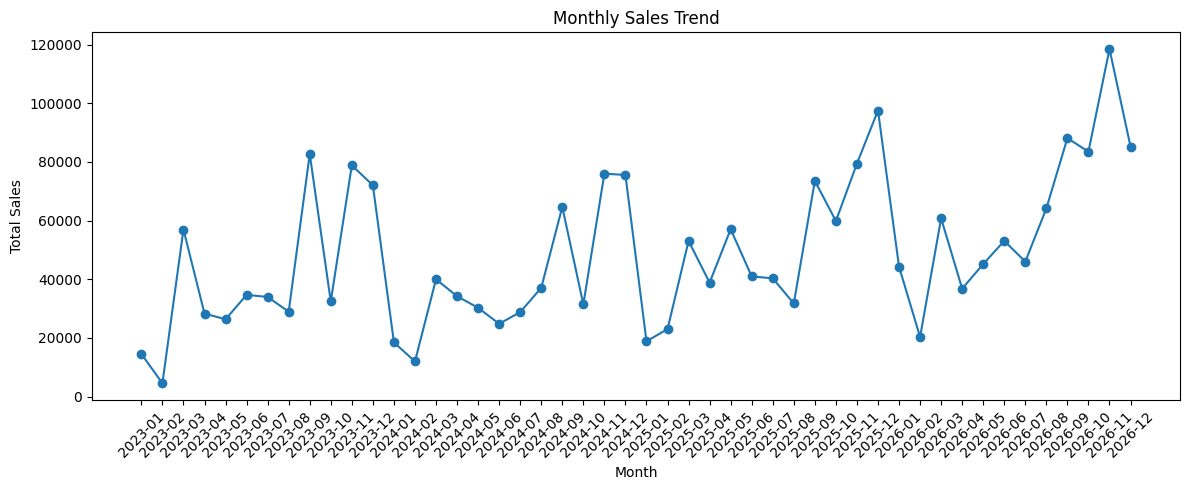

In [35]:
import matplotlib.pyplot as plt

# Create a proper month label
monthly_sales["month_label"] = (
    monthly_sales["order_year"].astype(str)
    + "-"
    + monthly_sales["order_month"].astype(str).str.zfill(2)
)

# Plot
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month_label"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

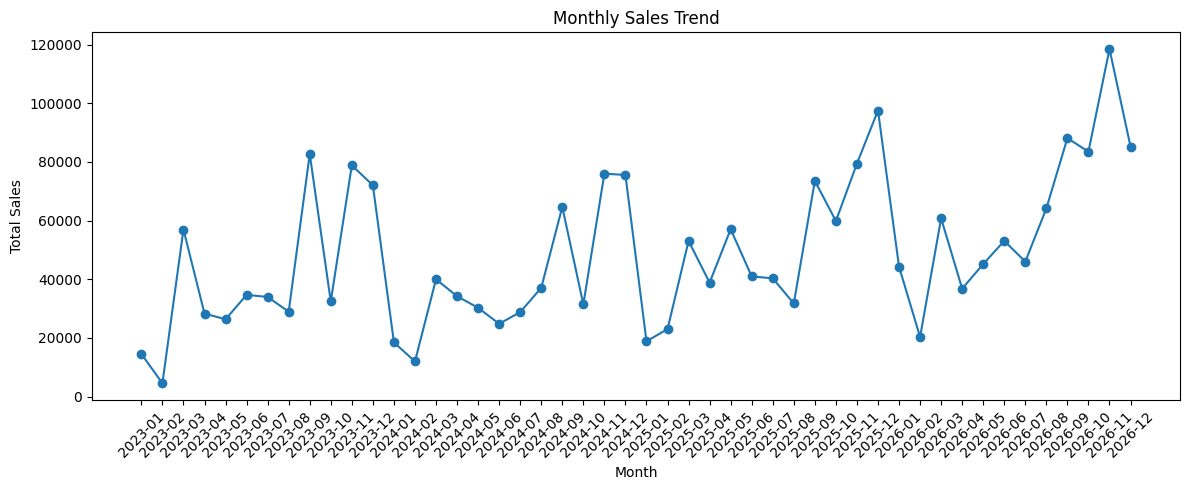

Chart saved at:
/content/charts/monthly_sales_trend.png


In [36]:
import os

# Create chart folder in Colab
os.makedirs("/content/charts", exist_ok=True)

chart_path = "/content/charts/monthly_sales_trend.png"

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month_label"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved at:")
print(chart_path)

In [37]:
# Find highest and lowest sales months

highest_month = monthly_sales.loc[
    monthly_sales["sales"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["sales"].idxmin()
]

print("Highest Sales Month:")
print(highest_month)

print("\nLowest Sales Month:")
print(lowest_month)

print("\nAverage Monthly Sales:")
print(monthly_sales["sales"].mean())

print("\nTotal Sales:")
print(monthly_sales["sales"].sum())

Highest Sales Month:
order_year           2026
order_month            11
sales          118454.505
month_label       2026-11
Name: 46, dtype: object

Lowest Sales Month:
order_year         2023
order_month           2
sales          4519.892
month_label     2023-02
Name: 1, dtype: object

Average Monthly Sales:
48469.465714583326

Total Sales:
2326534.3543


In [38]:
# Category-wise sales summary

category_sales = (
    eda_df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Category Sales Summary:")
display(category_sales)

Category Sales Summary:


,category,sales
0,Technology,839893.2790
1,Furniture,754747.7613
2,Office Supplies,731893.3140


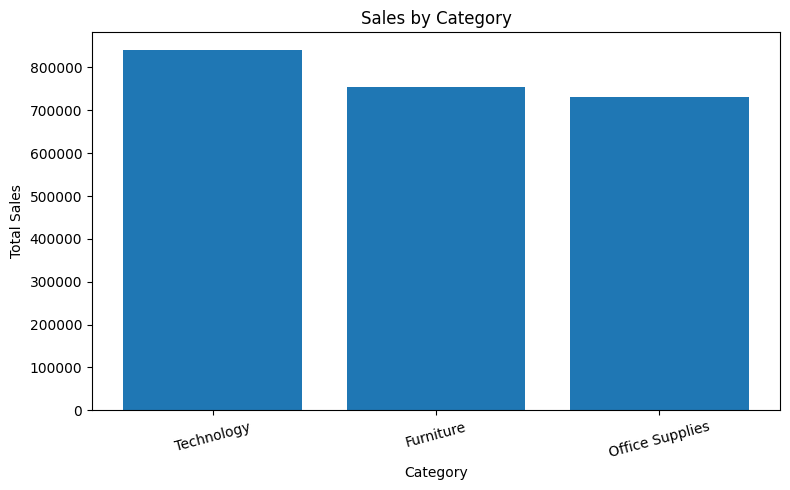

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales["category"],
    category_sales["sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

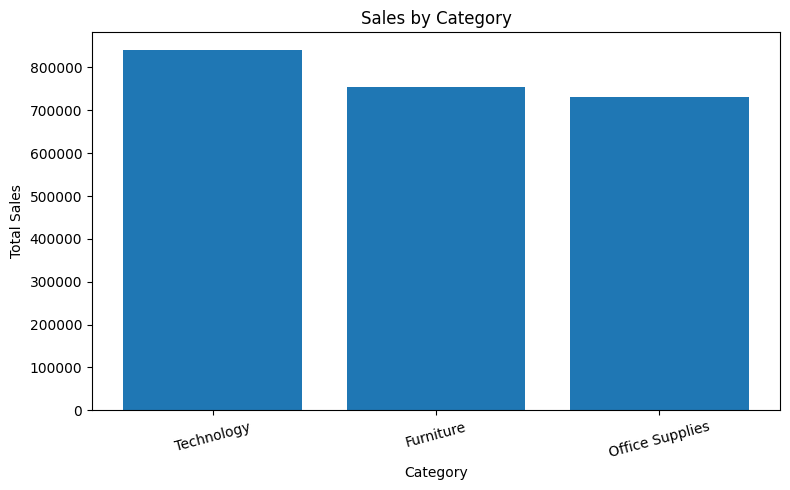

Chart saved at:
/content/charts/category_sales.png


In [40]:
import os

os.makedirs("/content/charts", exist_ok=True)

category_chart_path = "/content/charts/category_sales.png"

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales["category"],
    category_sales["sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(category_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved at:")
print(category_chart_path)

In [41]:
customer_segment_sales = (
    eda_df.groupby("customer_segment", observed=True)["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(customer_segment_sales)

,customer_segment,sales
0,High Value,1.243230e+06
1,Medium Value,6.743489e+05
2,Low Value,4.089556e+05


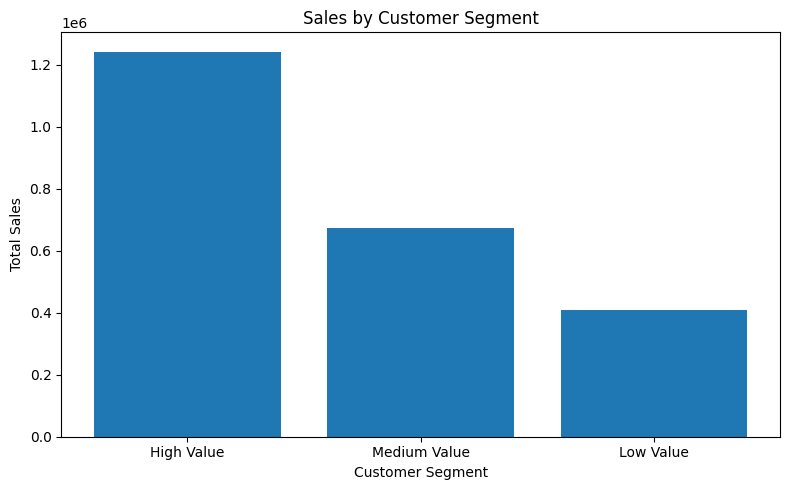

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    customer_segment_sales["customer_segment"],
    customer_segment_sales["sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()


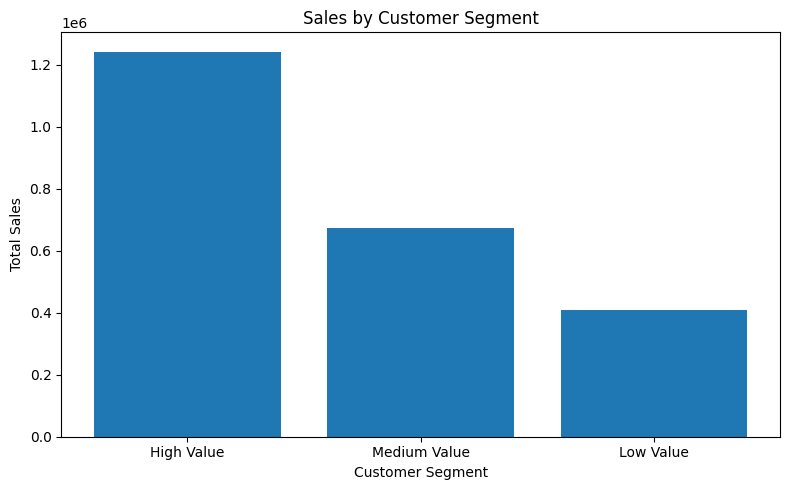

Chart saved at: /content/charts/customer_segment_sales.png


In [43]:
import os

os.makedirs("/content/charts", exist_ok=True)

customer_segment_chart_path = "/content/charts/customer_segment_sales.png"

plt.figure(figsize=(8, 5))

plt.bar(
    customer_segment_sales["customer_segment"],
    customer_segment_sales["sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig(customer_segment_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved at:", customer_segment_chart_path)

In [44]:
region_sales = (
    eda_df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(region_sales)

,region,sales
0,West,739813.6085
1,East,691828.1680
2,Central,503170.6728
3,South,391721.9050


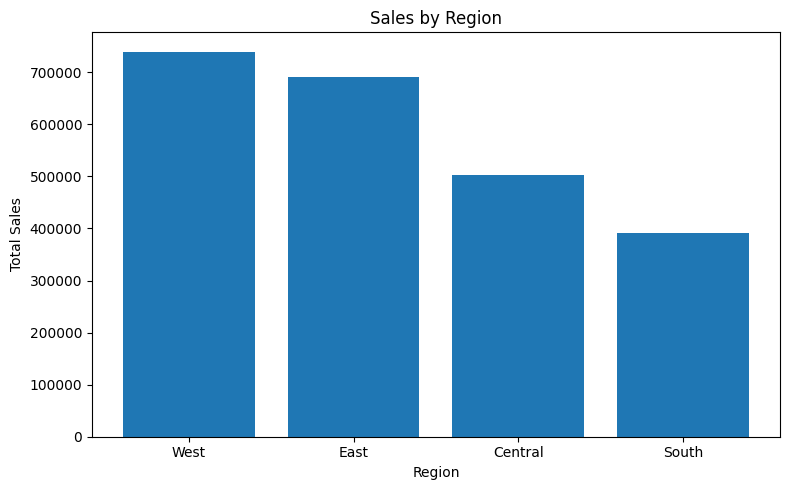

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["region"],
    region_sales["sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

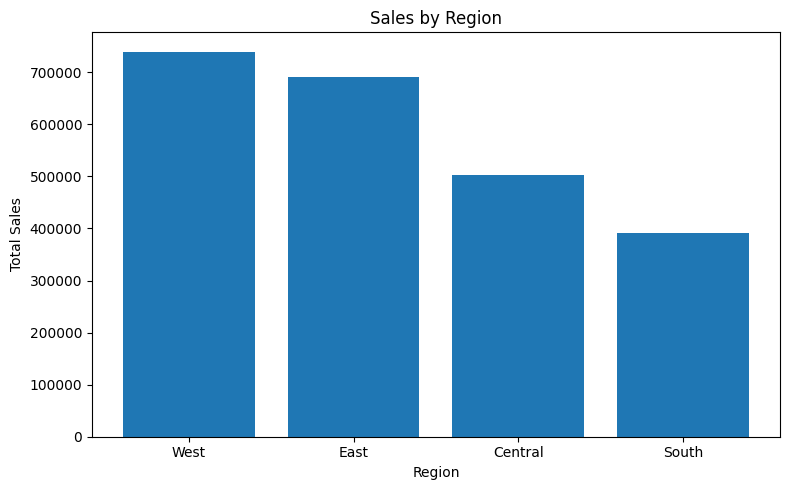

Chart saved at: /content/charts/regional_sales.png


In [46]:
import os

os.makedirs("/content/charts", exist_ok=True)

region_chart_path = "/content/charts/regional_sales.png"

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["region"],
    region_sales["sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig(region_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved at:", region_chart_path)

In [47]:
top_products_profit = (
    eda_df.groupby("product_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_products_profit)

,product_name,profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


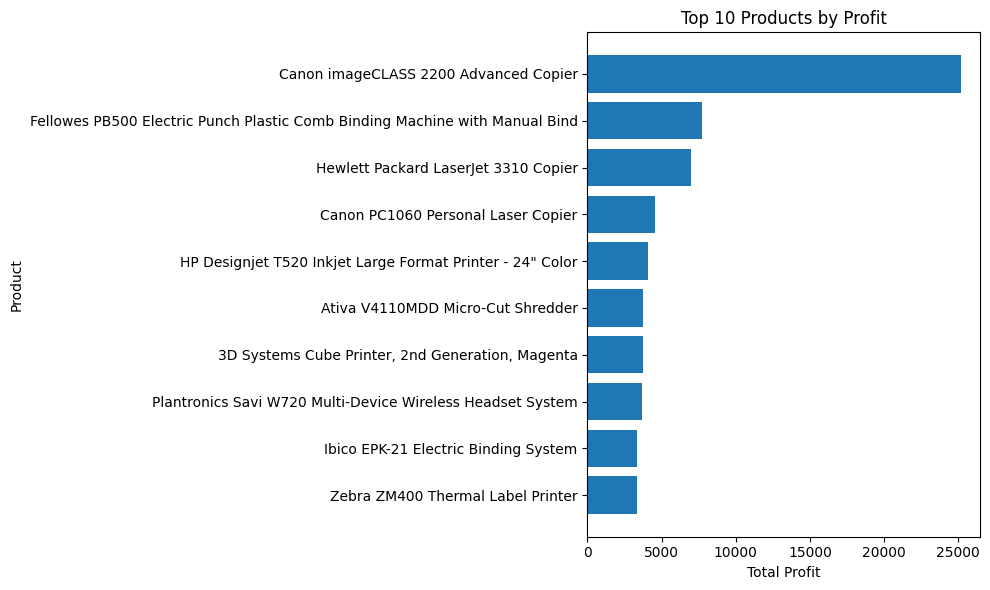

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_profit["product_name"],
    top_products_profit["profit"]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

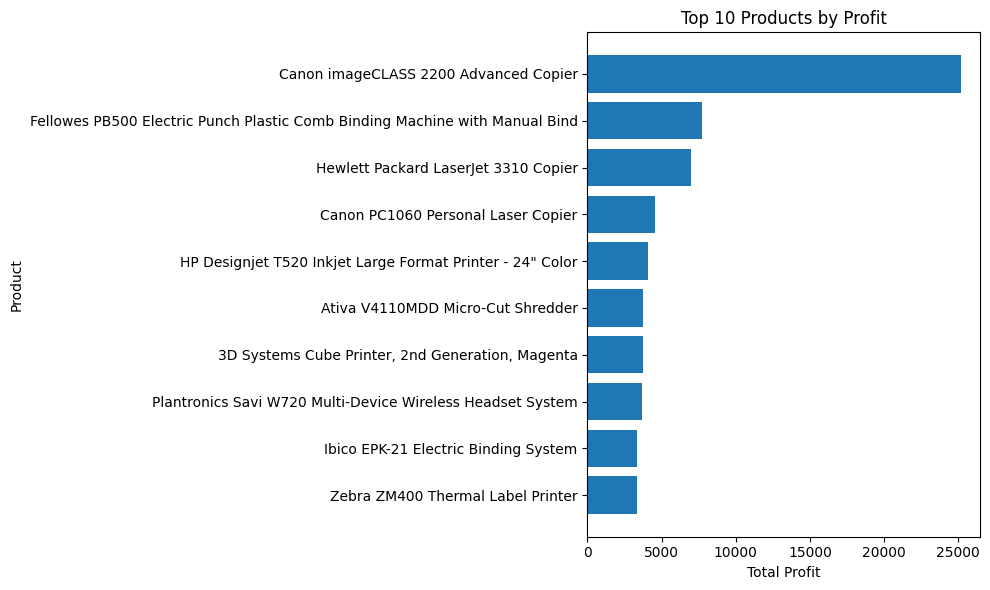

Chart saved at: /content/charts/top_products_profit.png


In [49]:
import os

os.makedirs("/content/charts", exist_ok=True)

top_products_chart_path = "/content/charts/top_products_profit.png"

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_profit["product_name"],
    top_products_profit["profit"]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(top_products_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved at:", top_products_chart_path)

In [50]:
import os

os.makedirs("/content/tables", exist_ok=True)

monthly_sales.to_csv(
    "/content/tables/monthly_sales.csv",
    index=False
)

category_sales.to_csv(
    "/content/tables/category_sales.csv",
    index=False
)

customer_segment_sales.to_csv(
    "/content/tables/customer_segment_sales.csv",
    index=False
)

region_sales.to_csv(
    "/content/tables/regional_sales.csv",
    index=False
)

top_products_profit.to_csv(
    "/content/tables/top_products_profit.csv",
    index=False
)

print("All EDA tables saved successfully!")

All EDA tables saved successfully!


In [51]:
print("===== MONTHLY SALES =====")
print("Highest Sales Month:")
print(monthly_sales.loc[monthly_sales["sales"].idxmax()])

print("\nLowest Sales Month:")
print(monthly_sales.loc[monthly_sales["sales"].idxmin()])


print("\n===== CATEGORY SALES =====")
print(category_sales)


print("\n===== CUSTOMER SEGMENT SALES =====")
print(customer_segment_sales)


print("\n===== REGIONAL SALES =====")
print(region_sales)


print("\n===== TOP 10 PRODUCTS BY PROFIT =====")
print(top_products_profit)

===== MONTHLY SALES =====
Highest Sales Month:
order_year           2026
order_month            11
sales          118454.505
month_label       2026-11
Name: 46, dtype: object

Lowest Sales Month:
order_year         2023
order_month           2
sales          4519.892
month_label     2023-02
Name: 1, dtype: object

===== CATEGORY SALES =====
          category        sales
0       Technology  839893.2790
1        Furniture  754747.7613
2  Office Supplies  731893.3140

===== CUSTOMER SEGMENT SALES =====
  customer_segment         sales
0       High Value  1.243230e+06
1     Medium Value  6.743489e+05
2        Low Value  4.089556e+05

===== REGIONAL SALES =====
    region        sales
0     West  739813.6085
1     East  691828.1680
2  Central  503170.6728
3    South  391721.9050

===== TOP 10 PRODUCTS BY PROFIT =====
                                        product_name      profit
0              Canon imageCLASS 2200 Advanced Copier  25199.9280
1  Fellowes PB500 Electric Punch Plastic Com

In [52]:
print("EDA OBSERVATIONS")
print("=" * 50)

highest_month = monthly_sales.loc[monthly_sales["sales"].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales["sales"].idxmin()]
highest_category = category_sales.iloc[0]
highest_segment = customer_segment_sales.iloc[0]
highest_region = region_sales.iloc[0]
highest_product = top_products_profit.iloc[0]

print(
    f"1. Highest monthly sales were recorded in "
    f"{highest_month['order_year']}-{int(highest_month['order_month']):02d} "
    f"with sales of {highest_month['sales']:,.2f}."
)

print(
    f"2. Lowest monthly sales were recorded in "
    f"{lowest_month['order_year']}-{int(lowest_month['order_month']):02d} "
    f"with sales of {lowest_month['sales']:,.2f}."
)

print(
    f"3. {highest_category['category']} generated the highest total sales "
    f"among the categories, with {highest_category['sales']:,.2f}."
)

print(
    f"4. {highest_segment['customer_segment']} generated the highest total sales "
    f"among the customer segments, with {highest_segment['sales']:,.2f}."
)

print(
    f"5. {highest_region['region']} generated the highest total sales "
    f"among the regions, with {highest_region['sales']:,.2f}."
)

print(
    f"6. The product with the highest total profit among the top 10 "
    f"was '{highest_product['product_name']}' with profit of "
    f"{highest_product['profit']:,.2f}."
)

EDA OBSERVATIONS
1. Highest monthly sales were recorded in 2026-11 with sales of 118,454.51.
2. Lowest monthly sales were recorded in 2023-02 with sales of 4,519.89.
3. Technology generated the highest total sales among the categories, with 839,893.28.
4. High Value generated the highest total sales among the customer segments, with 1,243,229.85.
5. West generated the highest total sales among the regions, with 739,813.61.
6. The product with the highest total profit among the top 10 was 'Canon imageCLASS 2200 Advanced Copier' with profit of 25,199.93.


In [53]:
observations = f"""
EDA OBSERVATIONS

1. Highest monthly sales were recorded in {highest_month['order_year']}-{int(highest_month['order_month']):02d} with sales of {highest_month['sales']:,.2f}.

2. Lowest monthly sales were recorded in {lowest_month['order_year']}-{int(lowest_month['order_month']):02d} with sales of {lowest_month['sales']:,.2f}.

3. {highest_category['category']} generated the highest total sales among the categories, with {highest_category['sales']:,.2f}.

4. {highest_segment['customer_segment']} generated the highest total sales among the customer segments, with {highest_segment['sales']:,.2f}.

5. {highest_region['region']} generated the highest total sales among the regions, with {highest_region['sales']:,.2f}.

6. The product with the highest total profit among the top 10 was '{highest_product['product_name']}' with profit of {highest_product['profit']:,.2f}.
"""

with open("/content/EDA_Observations.txt", "w", encoding="utf-8") as f:
    f.write(observations)

print("EDA observations saved successfully!")

EDA observations saved successfully!


In [54]:
total_sales = eda_df["sales"].sum()

highest_category_share = (
    highest_category["sales"] / total_sales * 100
)

highest_segment_share = (
    highest_segment["sales"] / total_sales * 100
)

highest_region_share = (
    highest_region["sales"] / total_sales * 100
)

month_difference = (
    highest_month["sales"] - lowest_month["sales"]
)

print("EDA INSIGHTS")
print("=" * 50)

print(
    f"1. {highest_category['category']} contributed "
    f"{highest_category_share:.2f}% of total sales."
)

print(
    f"2. {highest_segment['customer_segment']} contributed "
    f"{highest_segment_share:.2f}% of total sales."
)

print(
    f"3. {highest_region['region']} contributed "
    f"{highest_region_share:.2f}% of total sales."
)

print(
    f"4. The difference between the highest and lowest "
    f"monthly sales was {month_difference:,.2f}."
)

print(
    f"5. '{highest_product['product_name']}' generated "
    f"{highest_product['profit']:,.2f} in total profit among the top 10 products."
)

EDA INSIGHTS
1. Technology contributed 36.10% of total sales.
2. High Value contributed 53.44% of total sales.
3. West contributed 31.80% of total sales.
4. The difference between the highest and lowest monthly sales was 113,934.61.
5. 'Canon imageCLASS 2200 Advanced Copier' generated 25,199.93 in total profit among the top 10 products.


In [55]:
insights = f"""
EDA INSIGHTS

1. {highest_category['category']} contributed {highest_category_share:.2f}% of total sales.

2. {highest_segment['customer_segment']} contributed {highest_segment_share:.2f}% of total sales.

3. {highest_region['region']} contributed {highest_region_share:.2f}% of total sales.

4. The difference between the highest and lowest monthly sales was {month_difference:,.2f}.

5. '{highest_product['product_name']}' generated {highest_product['profit']:,.2f} in total profit among the top 10 products.
"""

with open("/content/EDA_Insights.txt", "w", encoding="utf-8") as f:
    f.write(insights)

print("EDA insights saved successfully!")

EDA insights saved successfully!


In [56]:
hypotheses = """
EDA HYPOTHESES

1. The higher sales contribution from the Technology category may be associated
   with higher-value products or stronger demand for Technology products.

2. The higher sales contribution from High Value customers may be associated
   with these customers placing larger or more frequent orders.

3. The higher sales contribution from the West region may be associated with
   differences in customer demand, order volume, or product mix in that region.
"""

print(hypotheses)

with open("/content/EDA_Hypotheses.txt", "w", encoding="utf-8") as f:
    f.write(hypotheses)

print("EDA hypotheses saved successfully!")


EDA HYPOTHESES

1. The higher sales contribution from the Technology category may be associated
   with higher-value products or stronger demand for Technology products.

2. The higher sales contribution from High Value customers may be associated
   with these customers placing larger or more frequent orders.

3. The higher sales contribution from the West region may be associated with
   differences in customer demand, order volume, or product mix in that region.

EDA hypotheses saved successfully!


In [57]:
# H1: Technology category — average order value
category_validation = (
    eda_df.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_order_value=("sales", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

print("HYPOTHESIS 1 VALIDATION")
display(category_validation)


# H2: High Value customers — order frequency
customer_frequency = (
    eda_df.groupby(["customer_id", "customer_segment"])
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("sales", "sum")
    )
    .reset_index()
)

segment_validation = (
    customer_frequency.groupby("customer_segment", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_orders=("order_count", "mean"),
        avg_customer_sales=("total_sales", "mean")
    )
    .reset_index()
)

print("HYPOTHESIS 2 VALIDATION")
display(segment_validation)


# H3: West region — order volume and product mix
region_validation = (
    eda_df.groupby("region")
    .agg(
        total_sales=("sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_order_value=("sales", "mean"),
        products=("product_id", "nunique")
    )
    .sort_values("total_sales", ascending=False)
)

print("HYPOTHESIS 3 VALIDATION")
display(region_validation)

HYPOTHESIS 1 VALIDATION


,total_sales,total_orders,avg_order_value
category,,,
Technology,839893.2790,1560,450.344922
Furniture,754747.7613,1819,342.911295
Office Supplies,731893.3140,3812,119.434288


HYPOTHESIS 2 VALIDATION


,customer_segment,customers,avg_orders,avg_customer_sales
0,High Value,189,8.132275,6577.935720
1,Low Value,383,4.997389,1067.769206
2,Medium Value,232,7.181034,2906.676282


HYPOTHESIS 3 VALIDATION


,total_sales,total_orders,avg_order_value,products
region,,,,
West,739813.6085,1635,227.425026,1509
East,691828.1680,1475,231.690612,1427
Central,503170.6728,1179,215.490652,1310
South,391721.9050,822,241.803645,1057


In [58]:
# Get the relevant rows
technology = category_validation.loc["Technology"]
high_value = segment_validation[
    segment_validation["customer_segment"] == "High Value"
].iloc[0]
west = region_validation.loc["West"]

# Compare against other categories/segments/regions
other_categories = category_validation.drop("Technology")
other_segments = segment_validation[
    segment_validation["customer_segment"] != "High Value"
]
other_regions = region_validation.drop("West")

# Hypothesis 1
h1_supported = (
    technology["avg_order_value"] > other_categories["avg_order_value"].mean()
)

# Hypothesis 2
h2_supported = (
    high_value["avg_orders"] > other_segments["avg_orders"].mean()
)

# Hypothesis 3
h3_supported = (
    west["total_orders"] > other_regions["total_orders"].mean()
)

validation_summary = f"""
HYPOTHESIS VALIDATION SUMMARY

1. Technology Category:
Hypothesis: Higher sales may be associated with higher-value products or stronger demand.
Average order value for Technology: {technology['avg_order_value']:,.2f}
Result: {"Supported by the tested metric." if h1_supported else "Not supported by the tested metric."}

2. High Value Customers:
Hypothesis: Higher sales may be associated with larger or more frequent orders.
Average orders for High Value customers: {high_value['avg_orders']:,.2f}
Result: {"Supported by the tested metric." if h2_supported else "Not supported by the tested metric."}

3. West Region:
Hypothesis: Higher sales may be associated with differences in demand or order volume.
Total orders in West: {west['total_orders']:,}
Result: {"Supported by the tested metric." if h3_supported else "Not supported by the tested metric."}
"""

print(validation_summary)

with open("/content/EDA_Hypothesis_Validation.txt", "w", encoding="utf-8") as f:
    f.write(validation_summary)

print("Validation summary saved successfully!")


HYPOTHESIS VALIDATION SUMMARY

1. Technology Category:
Hypothesis: Higher sales may be associated with higher-value products or stronger demand.
Average order value for Technology: 450.34
Result: Supported by the tested metric.

2. High Value Customers:
Hypothesis: Higher sales may be associated with larger or more frequent orders.
Average orders for High Value customers: 8.13
Result: Supported by the tested metric.

3. West Region:
Hypothesis: Higher sales may be associated with differences in demand or order volume.
Total orders in West: 1,635.0
Result: Supported by the tested metric.

Validation summary saved successfully!


In [59]:
recommendations = f"""
BUSINESS RECOMMENDATIONS

1. Category Strategy:
Focus on understanding and supporting the demand for the {highest_category['category']}
category, which generated the highest total sales. Further analysis of its products,
customers, and order patterns can help identify opportunities for growth.

2. Customer Strategy:
The {highest_segment['customer_segment']} segment contributes the highest sales.
The business can study the purchasing behaviour of these customers and develop
appropriate retention and engagement strategies.

3. Regional Strategy:
The {highest_region['region']} region contributes the highest total sales.
The business can investigate the product mix, customer demand, and order patterns
in this region to identify factors associated with its sales performance.
"""

print(recommendations)

with open("/content/EDA_Recommendations.txt", "w", encoding="utf-8") as f:
    f.write(recommendations)

print("EDA recommendations saved successfully!")


BUSINESS RECOMMENDATIONS

1. Category Strategy:
Focus on understanding and supporting the demand for the Technology
category, which generated the highest total sales. Further analysis of its products,
customers, and order patterns can help identify opportunities for growth.

2. Customer Strategy:
The High Value segment contributes the highest sales.
The business can study the purchasing behaviour of these customers and develop
appropriate retention and engagement strategies.

3. Regional Strategy:
The West region contributes the highest total sales.
The business can investigate the product mix, customer demand, and order patterns
in this region to identify factors associated with its sales performance.

EDA recommendations saved successfully!


In [60]:
print("===== EDA FINAL CHECK =====")

print("Dataset shape:", eda_df.shape)

print("\nCharts:")
print("1. Monthly Sales Trend")
print("2. Sales by Category")
print("3. Sales by Customer Segment")
print("4. Sales by Region")
print("5. Top 10 Products by Profit")

print("\nTables:")
print("1. monthly_sales.csv")
print("2. category_sales.csv")
print("3. customer_segment_sales.csv")
print("4. regional_sales.csv")
print("5. top_products_profit.csv")

print("\nAnalysis Files:")
print("1. EDA_Observations.txt")
print("2. EDA_Insights.txt")
print("3. EDA_Hypotheses.txt")
print("4. EDA_Hypothesis_Validation.txt")
print("5. EDA_Recommendations.txt")

print("\nEDA stage completed successfully!")

===== EDA FINAL CHECK =====
Dataset shape: (10194, 26)

Charts:
1. Monthly Sales Trend
2. Sales by Category
3. Sales by Customer Segment
4. Sales by Region
5. Top 10 Products by Profit

Tables:
1. monthly_sales.csv
2. category_sales.csv
3. customer_segment_sales.csv
4. regional_sales.csv
5. top_products_profit.csv

Analysis Files:
1. EDA_Observations.txt
2. EDA_Insights.txt
3. EDA_Hypotheses.txt
4. EDA_Hypothesis_Validation.txt
5. EDA_Recommendations.txt

EDA stage completed successfully!


In [61]:
customer_df = (
    eda_df.groupby("customer_id")
    .agg(
        customer_name=("customer_name", "first"),
        last_order_date=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("sales", "sum")
    )
    .reset_index()
)

display(customer_df.head())

print("Customer-level dataset shape:", customer_df.shape)

,customer_id,customer_name,last_order_date,frequency,monetary
0,AA-10315,Alex Avila,2026-06-29,5,5563.560
1,AA-10375,Allen Armold,2026-12-11,9,1056.390
2,AA-10480,Andrew Allen,2026-04-15,4,1790.512
3,AA-10645,Anna Andreadi,2026-11-05,6,5086.935
4,AB-10015,Aaron Bergman,2025-11-10,3,886.156


Customer-level dataset shape: (804, 5)


In [62]:
reference_date = eda_df["order_date"].max()

customer_df["recency"] = (
    reference_date - customer_df["last_order_date"]
).dt.days

display(
    customer_df[
        ["customer_id", "last_order_date", "recency", "frequency", "monetary"]
    ].head()
)

print("Reference date:", reference_date)

,customer_id,last_order_date,recency,frequency,monetary
0,AA-10315,2026-06-29,184,5,5563.560
1,AA-10375,2026-12-11,19,9,1056.390
2,AA-10480,2026-04-15,259,4,1790.512
3,AA-10645,2026-11-05,55,6,5086.935
4,AB-10015,2025-11-10,415,3,886.156


Reference date: 2026-12-30 00:00:00


In [63]:
print("Missing values in RFM features:")
print(
    customer_df[
        ["recency", "frequency", "monetary"]
    ].isnull().sum()
)

print("\nRFM Summary:")
display(
    customer_df[
        ["recency", "frequency", "monetary"]
    ].describe()
)

Missing values in RFM features:
recency      0
frequency    0
monetary     0
dtype: int64

RFM Summary:


,recency,frequency,monetary
count,804.000000,804.000000,804.000000
mean,146.016169,6.364428,2893.699446
std,185.551511,2.660121,2653.778471
min,0.000000,1.000000,4.833000
25%,29.000000,5.000000,1084.538000
50%,75.000000,6.000000,2243.392000
75%,180.750000,8.000000,3790.812100
max,1165.000000,17.000000,25043.050000


In [64]:
customer_df["churn"] = (
    customer_df["recency"] >= 180
).astype(int)

print("Churn distribution:")
print(customer_df["churn"].value_counts())

print("\nChurn percentage:")
print(customer_df["churn"].value_counts(normalize=True) * 100)

Churn distribution:
churn
0    600
1    204
Name: count, dtype: int64

Churn percentage:
churn
0    74.626866
1    25.373134
Name: proportion, dtype: float64


In [65]:
churn_distribution = (
    customer_df["churn"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Not Churned",
        1: "Churned"
    })
)

display(churn_distribution)

print("\nChurn Percentage:")
display(
    (customer_df["churn"]
     .value_counts(normalize=True)
     .sort_index()
     .rename(index={
         0: "Not Churned",
         1: "Churned"
     }) * 100)
)

,count
churn,
Not Churned,600
Churned,204



Churn Percentage:


,proportion
churn,
Not Churned,74.626866
Churned,25.373134


In [66]:
features = ["recency", "frequency", "monetary"]

X = customer_df[features]
y = customer_df["churn"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):


,recency,frequency,monetary
0,184,5,5563.560
1,19,9,1056.390
2,259,4,1790.512
3,55,6,5086.935
4,415,3,886.156



Target (y):


,churn
0,1
1,0
2,1
3,0
4,1



X shape: (804, 3)
y shape: (804,)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (643, 3)
Testing data shape: (161, 3)

Training target distribution:
churn
0    480
1    163
Name: count, dtype: int64

Testing target distribution:
churn
0    120
1     41
Name: count, dtype: int64


In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [69]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nPredicted Churn Status:")
print(y_pred[:10])

print("\nChurn Probabilities:")
print(y_probability[:10])

Predictions generated successfully!

Predicted Churn Status:
[0 0 0 1 0 0 0 0 0 1]

Churn Probabilities:
[2.13807612e-72 1.30121535e-50 2.16454081e-57 1.00000000e+00
 1.98232116e-65 5.99863133e-69 1.45733836e-50 5.54996806e-28
 4.61854504e-68 1.00000000e+00]


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

cm = confusion_matrix(y_test, y_pred)

print("MODEL EVALUATION")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

print("\nConfusion Matrix:")
print(cm)

MODEL EVALUATION
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000

Confusion Matrix:
[[120   0]
 [  0  41]]


In [71]:
prediction_results = customer_df.loc[
    X_test.index,
    ["customer_id"]
].copy()

prediction_results["actual_churn_status"] = y_test
prediction_results["predicted_churn_status"] = y_pred
prediction_results["churn_probability"] = y_probability

prediction_results = prediction_results.reset_index(drop=True)

display(prediction_results.head(10))

,customer_id,actual_churn_status,predicted_churn_status,churn_probability
0,CS-11950,0,0,2.138076e-72
1,HH-15010,0,0,1.301215e-50
2,PG-18895,0,0,2.164541e-57
3,MS-17830,1,1,1.000000e+00
4,ME-17320,0,0,1.982321e-65
5,JR-16210,0,0,5.998631e-69
6,MO-17500,0,0,1.457338e-50
7,SS-20875,0,0,5.549968e-28
8,FG-14260,0,0,4.618545e-68
9,SC-20020,1,1,1.000000e+00


In [72]:
prediction_output_path = "/content/churn_prediction_results.csv"

prediction_results.to_csv(
    prediction_output_path,
    index=False
)

print("Prediction results saved successfully!")
print("File:", prediction_output_path)

Prediction results saved successfully!
File: /content/churn_prediction_results.csv


In [73]:
print("Current ML features:")
print(features)

print("\nTarget definition:")
print("Churn = 1 when Recency >= 180 days")

print("\n⚠️ Leakage check:")
if "recency" in features:
    print("WARNING: Recency is directly used to create the churn target.")
    print("We need to redesign the feature/target setup before finalizing the model.")

Current ML features:
['recency', 'frequency', 'monetary']

Target definition:
Churn = 1 when Recency >= 180 days

⚠️ Leakage check:
We need to redesign the feature/target setup before finalizing the model.


In [74]:
snapshot_date = eda_df["order_date"].max() - pd.Timedelta(days=180)

observation_start = eda_df["order_date"].min()

print("Observation period starts:", observation_start)
print("Snapshot date:", snapshot_date)
print("Dataset end date:", eda_df["order_date"].max())
print("Future observation period:", snapshot_date + pd.Timedelta(days=1),
      "to", eda_df["order_date"].max())

Observation period starts: 2023-01-03 00:00:00
Snapshot date: 2026-07-03 00:00:00
Dataset end date: 2026-12-30 00:00:00
Future observation period: 2026-07-04 00:00:00 to 2026-12-30 00:00:00


In [75]:
historical_data = eda_df[
    eda_df["order_date"] <= snapshot_date
].copy()

historical_customer_df = (
    historical_data.groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("sales", "sum")
    )
    .reset_index()
)

historical_customer_df["recency"] = (
    snapshot_date - historical_customer_df["last_order_date"]
).dt.days

print("Historical customer dataset shape:",
      historical_customer_df.shape)

display(historical_customer_df.head())

Historical customer dataset shape: (799, 5)


,customer_id,last_order_date,frequency,monetary,recency
0,AA-10315,2026-06-29,5,5563.560,4
1,AA-10375,2025-11-14,7,849.658,231
2,AA-10480,2026-04-15,4,1790.512,79
3,AA-10645,2025-09-04,5,5073.975,302
4,AB-10015,2025-11-10,3,886.156,235


In [76]:
future_data = eda_df[
    eda_df["order_date"] > snapshot_date
].copy()

future_activity = (
    future_data.groupby("customer_id")
    .agg(
        future_orders=("order_id", "nunique"),
        future_sales=("sales", "sum")
    )
    .reset_index()
)

historical_customer_df = historical_customer_df.merge(
    future_activity,
    on="customer_id",
    how="left"
)

historical_customer_df["future_orders"] = (
    historical_customer_df["future_orders"].fillna(0)
)

historical_customer_df["future_sales"] = (
    historical_customer_df["future_sales"].fillna(0)
)

display(historical_customer_df.head())

print("Historical customer dataset shape:",
      historical_customer_df.shape)

,customer_id,last_order_date,frequency,monetary,recency,future_orders,future_sales
0,AA-10315,2026-06-29,5,5563.560,4,0.0,0.000
1,AA-10375,2025-11-14,7,849.658,231,2.0,206.732
2,AA-10480,2026-04-15,4,1790.512,79,0.0,0.000
3,AA-10645,2025-09-04,5,5073.975,302,1.0,12.960
4,AB-10015,2025-11-10,3,886.156,235,0.0,0.000


Historical customer dataset shape: (799, 7)


In [77]:
historical_customer_df["churn"] = (
    historical_customer_df["future_orders"] == 0
).astype(int)

print("Historical Churn Distribution:")
print(
    historical_customer_df["churn"]
    .value_counts()
    .rename(index={
        0: "Not Churned",
        1: "Churned"
    })
)

print("\nHistorical Churn Percentage:")
print(
    (
        historical_customer_df["churn"]
        .value_counts(normalize=True)
        .rename(index={
            0: "Not Churned",
            1: "Churned"
        }) * 100
    )
)

Historical Churn Distribution:
churn
Not Churned    595
Churned        204
Name: count, dtype: int64

Historical Churn Percentage:
churn
Not Churned    74.468085
Churned        25.531915
Name: proportion, dtype: float64


In [78]:
ml_features = ["recency", "frequency", "monetary"]

X_hist = historical_customer_df[ml_features]
y_hist = historical_customer_df["churn"]

print("Features:")
display(X_hist.head())

print("\nTarget:")
display(y_hist.head())

print("\nX shape:", X_hist.shape)
print("y shape:", y_hist.shape)

Features:


,recency,frequency,monetary
0,4,5,5563.560
1,231,7,849.658
2,79,4,1790.512
3,302,5,5073.975
4,235,3,886.156



Target:


,churn
0,1
1,0
2,1
3,0
4,1



X shape: (799, 3)
y shape: (799,)


In [79]:
from sklearn.model_selection import train_test_split

X_train_hist, X_test_hist, y_train_hist, y_test_hist = train_test_split(
    X_hist,
    y_hist,
    test_size=0.20,
    random_state=42,
    stratify=y_hist
)

print("Training data shape:", X_train_hist.shape)
print("Testing data shape:", X_test_hist.shape)

print("\nTraining target distribution:")
print(y_train_hist.value_counts())

print("\nTesting target distribution:")
print(y_test_hist.value_counts())

Training data shape: (639, 3)
Testing data shape: (160, 3)

Training target distribution:
churn
0    476
1    163
Name: count, dtype: int64

Testing target distribution:
churn
0    119
1     41
Name: count, dtype: int64


In [80]:
from sklearn.linear_model import LogisticRegression

historical_model = LogisticRegression(max_iter=1000)

historical_model.fit(
    X_train_hist,
    y_train_hist
)

print("Leakage-free Logistic Regression model trained successfully!")

Leakage-free Logistic Regression model trained successfully!


In [81]:
y_pred_hist = historical_model.predict(X_test_hist)

y_probability_hist = historical_model.predict_proba(X_test_hist)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 Predicted Churn Status:")
print(y_pred_hist[:10])

print("\nFirst 10 Churn Probabilities:")
print(y_probability_hist[:10])

Predictions generated successfully!

First 10 Predicted Churn Status:
[0 0 0 0 0 0 0 0 0 0]

First 10 Churn Probabilities:
[0.23935156 0.2589967  0.27202824 0.23589459 0.30802723 0.23529727
 0.24338198 0.27527672 0.24083798 0.23414392]


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

accuracy_hist = accuracy_score(y_test_hist, y_pred_hist)
precision_hist = precision_score(
    y_test_hist,
    y_pred_hist,
    zero_division=0
)
recall_hist = recall_score(
    y_test_hist,
    y_pred_hist,
    zero_division=0
)

cm_hist = confusion_matrix(
    y_test_hist,
    y_pred_hist
)

print("FINAL MODEL EVALUATION")
print("=" * 40)

print(f"Accuracy : {accuracy_hist:.4f}")
print(f"Precision: {precision_hist:.4f}")
print(f"Recall   : {recall_hist:.4f}")

print("\nConfusion Matrix:")
print(cm_hist)

FINAL MODEL EVALUATION
Accuracy : 0.7438
Precision: 0.0000
Recall   : 0.0000

Confusion Matrix:
[[119   0]
 [ 41   0]]


In [83]:
final_prediction_results = historical_customer_df.loc[
    X_test_hist.index,
    ["customer_id"]
].copy()

final_prediction_results["actual_churn_status"] = y_test_hist
final_prediction_results["predicted_churn_status"] = y_pred_hist
final_prediction_results["churn_probability"] = y_probability_hist

final_prediction_results = final_prediction_results.reset_index(drop=True)

display(final_prediction_results.head(10))

,customer_id,actual_churn_status,predicted_churn_status,churn_probability
0,KH-16360,0,0,0.239352
1,PB-19150,0,0,0.258997
2,DK-13375,0,0,0.272028
3,HP-14815,0,0,0.235895
4,DL-12925,0,0,0.308027
5,SC-20050,0,0,0.235297
6,ML-17410,0,0,0.243382
7,TB-21520,0,0,0.275277
8,CS-11860,0,0,0.240838
9,KM-16375,0,0,0.234144


In [84]:
final_prediction_path = "/content/final_churn_predictions.csv"

final_prediction_results.to_csv(
    final_prediction_path,
    index=False
)

print("Final churn predictions saved successfully!")
print("File:", final_prediction_path)

Final churn predictions saved successfully!
File: /content/final_churn_predictions.csv


In [85]:
metrics_text = f"""
MODEL EVALUATION RESULTS

Model: Logistic Regression

Accuracy: {accuracy_hist:.4f}
Precision: {precision_hist:.4f}
Recall: {recall_hist:.4f}

Confusion Matrix:
{cm_hist}
"""

with open("/content/model_evaluation.txt", "w", encoding="utf-8") as f:
    f.write(metrics_text)

print("Model evaluation results saved successfully!")
print(metrics_text)

Model evaluation results saved successfully!

MODEL EVALUATION RESULTS

Model: Logistic Regression

Accuracy: 0.7438
Precision: 0.0000
Recall: 0.0000

Confusion Matrix:
[[119   0]
 [ 41   0]]



In [86]:
feature_importance = pd.DataFrame({
    "feature": ml_features,
    "coefficient": historical_model.coef_[0]
})

feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(feature_importance)

,feature,coefficient,absolute_coefficient
1,frequency,-0.053684,0.053684
0,recency,0.000601,0.000601
2,monetary,0.000012,0.000012


In [87]:
feature_importance_path = "/content/feature_importance.csv"

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("Feature importance saved successfully!")
print("File:", feature_importance_path)

Feature importance saved successfully!
File: /content/feature_importance.csv


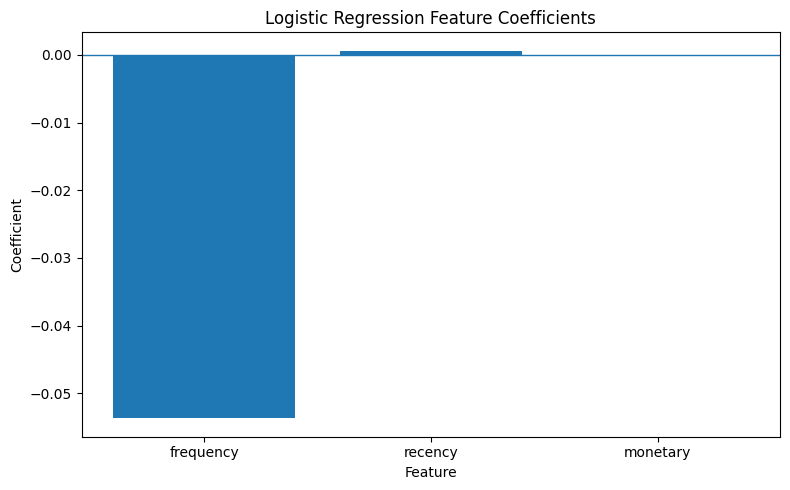

In [88]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["feature"],
    feature_importance["coefficient"]
)

plt.axhline(0, linewidth=1)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient")

plt.tight_layout()
plt.show()

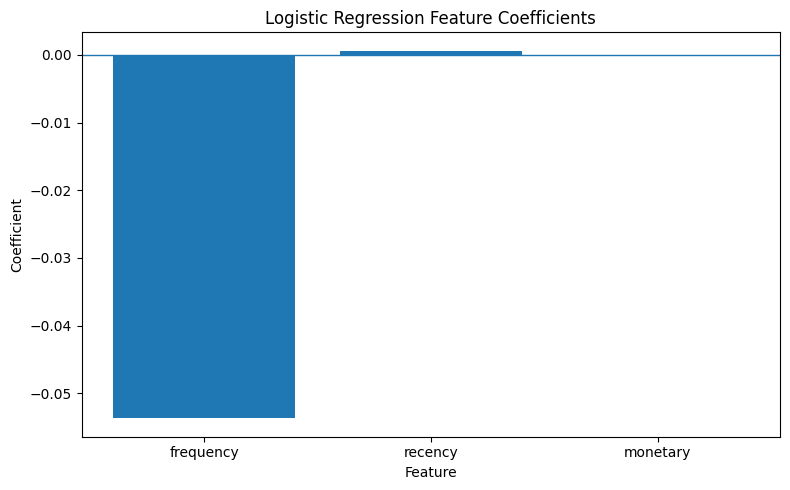

Feature importance chart saved at: /content/charts/feature_importance.png


In [89]:
feature_chart_path = "/content/charts/feature_importance.png"

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["feature"],
    feature_importance["coefficient"]
)

plt.axhline(0, linewidth=1)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient")

plt.tight_layout()
plt.savefig(feature_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Feature importance chart saved at:", feature_chart_path)

In [90]:
historical_dataset_path = "/content/historical_customer_churn_dataset.csv"

historical_customer_df.to_csv(
    historical_dataset_path,
    index=False
)

print("Historical customer churn dataset saved successfully!")
print("File:", historical_dataset_path)

Historical customer churn dataset saved successfully!
File: /content/historical_customer_churn_dataset.csv


In [91]:
model_summary = f"""
MACHINE LEARNING MODEL SUMMARY

Model:
Logistic Regression

Features:
- Recency
- Frequency
- Monetary

Historical Snapshot Date:
{snapshot_date}

Target:
Churn = 1 when the customer placed no order during the
180-day future observation period after the snapshot date.

Evaluation Metrics:
Accuracy  : {accuracy_hist:.4f}
Precision : {precision_hist:.4f}
Recall    : {recall_hist:.4f}

Confusion Matrix:
{cm_hist}

Important Note:
The model uses historical customer behaviour available before
the snapshot date to avoid target leakage.
"""

with open("/content/ML_Model_Summary.txt", "w", encoding="utf-8") as f:
    f.write(model_summary)

print(model_summary)
print("\nML model summary saved successfully!")


MACHINE LEARNING MODEL SUMMARY

Model:
Logistic Regression

Features:
- Recency
- Frequency
- Monetary

Historical Snapshot Date:
2026-07-03 00:00:00

Target:
Churn = 1 when the customer placed no order during the
180-day future observation period after the snapshot date.

Evaluation Metrics:
Accuracy  : 0.7438
Precision : 0.0000
Recall    : 0.0000

Confusion Matrix:
[[119   0]
 [ 41   0]]

Important Note:
The model uses historical customer behaviour available before
the snapshot date to avoid target leakage.


ML model summary saved successfully!


In [92]:
import os

ml_files = [
    "/content/final_churn_predictions.csv",
    "/content/feature_importance.csv",
    "/content/historical_customer_churn_dataset.csv",
    "/content/model_evaluation.txt",
    "/content/ML_Model_Summary.txt",
    "/content/charts/feature_importance.png"
]

print("ML OUTPUT FILE CHECK")
print("=" * 40)

for file_path in ml_files:
    status = "✓ Found" if os.path.exists(file_path) else "✗ Missing"
    print(f"{status}: {file_path}")

ML OUTPUT FILE CHECK
✓ Found: /content/final_churn_predictions.csv
✓ Found: /content/feature_importance.csv
✓ Found: /content/historical_customer_churn_dataset.csv
✓ Found: /content/model_evaluation.txt
✓ Found: /content/ML_Model_Summary.txt
✓ Found: /content/charts/feature_importance.png


In [93]:
import os
import shutil

os.makedirs("/content/project_outputs/Charts", exist_ok=True)
os.makedirs("/content/project_outputs/Tables", exist_ok=True)
os.makedirs("/content/project_outputs/Model", exist_ok=True)

# Charts
for file in [
    "monthly_sales_trend.png",
    "category_sales.png",
    "customer_segment_sales.png",
    "regional_sales.png",
    "top_products_profit.png",
    "feature_importance.png"
]:
    source = f"/content/charts/{file}"
    if os.path.exists(source):
        shutil.copy(source, f"/content/project_outputs/Charts/{file}")

# EDA tables
for file in [
    "monthly_sales.csv",
    "category_sales.csv",
    "customer_segment_sales.csv",
    "regional_sales.csv",
    "top_products_profit.csv"
]:
    source = f"/content/tables/{file}"
    if os.path.exists(source):
        shutil.copy(source, f"/content/project_outputs/Tables/{file}")

# Model outputs
for file in [
    "final_churn_predictions.csv",
    "feature_importance.csv",
    "historical_customer_churn_dataset.csv",
    "model_evaluation.txt",
    "ML_Model_Summary.txt"
]:
    source = f"/content/{file}"
    if os.path.exists(source):
        shutil.copy(source, f"/content/project_outputs/Model/{file}")

print("Project output files prepared successfully!")

Project output files prepared successfully!


In [94]:
requirements = """pandas
numpy
matplotlib
scikit-learn
xlrd
openpyxl
"""

with open("/content/requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully!")
print(requirements)

requirements.txt created successfully!
pandas
numpy
matplotlib
scikit-learn
xlrd
openpyxl



In [95]:
from google.colab import files

files.download("/content/requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>